# FOLIO Analysis: Why CoT Outperforms Lean Verification

This notebook analyzes three approaches to FOLIO logical reasoning:
1. **CoT**: Zero-shot chain-of-thought reasoning in natural language
2. **Lean**: Direct Lean 4 formal verification with iterative refinement
3. **Two-Stage**: Bidirectional iteration (Stage 1: natural language → Stage 2: Lean verification)

**Key Question**: Why does formal verification hurt rather than help performance?

Dataset: FOLIO validation set (203 questions), Model: gpt-5

In [75]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load and Prepare Data

In [76]:
# Load all three result sets
with open('../results/folio/cot/all_results.json', 'r') as f:
    cot_results = json.load(f)

with open('../results/folio/lean/all_results.json', 'r') as f:
    lean_results = json.load(f)

with open('../results/folio/two_stage/all_results.json', 'r') as f:
    two_stage_results = json.load(f)

# Flatten CoT (nested structure: stories → results)
cot_flat = []
for story in cot_results:
    if 'results' in story:
        for result in story['results']:
            cot_flat.append(result)

# Sort all by example_id for alignment
cot_sorted = sorted(cot_flat, key=lambda x: x.get('example_id'))
lean_sorted = sorted(lean_results, key=lambda x: x.get('example_id'))
two_stage_sorted = sorted(two_stage_results, key=lambda x: x.get('example_id'))

# Calculate accuracies
cot_acc = sum(1 for r in cot_sorted if r['correct']) / len(cot_sorted) * 100
lean_acc = sum(1 for r in lean_sorted if r['correct']) / len(lean_sorted) * 100
two_stage_acc = sum(1 for r in two_stage_sorted if r['correct']) / len(two_stage_sorted) * 100

print(f"Loaded {len(cot_sorted)} questions from each approach")
print(f"\n{'='*70}")
print("OVERALL PERFORMANCE")
print('='*70)
print(f"CoT:       {cot_acc:.2f}% ({sum(1 for r in cot_sorted if r['correct'])}/{len(cot_sorted)})")
print(f"Two-Stage: {two_stage_acc:.2f}% ({sum(1 for r in two_stage_sorted if r['correct'])}/{len(two_stage_sorted)})")
print(f"Lean:      {lean_acc:.2f}% ({sum(1 for r in lean_sorted if r['correct'])}/{len(lean_sorted)})")
print(f"\nCoT outperforms Lean by: {cot_acc - lean_acc:.2f}%")
print(f"Two-Stage improves over Lean by: {two_stage_acc - lean_acc:.2f}%")
print('='*70)

Loaded 203 questions from each approach

OVERALL PERFORMANCE
CoT:       85.71% (174/203)
Two-Stage: 79.31% (161/203)
Lean:      74.88% (152/203)

CoT outperforms Lean by: 10.84%
Two-Stage improves over Lean by: 4.43%


## 2. Overall Performance Visualization

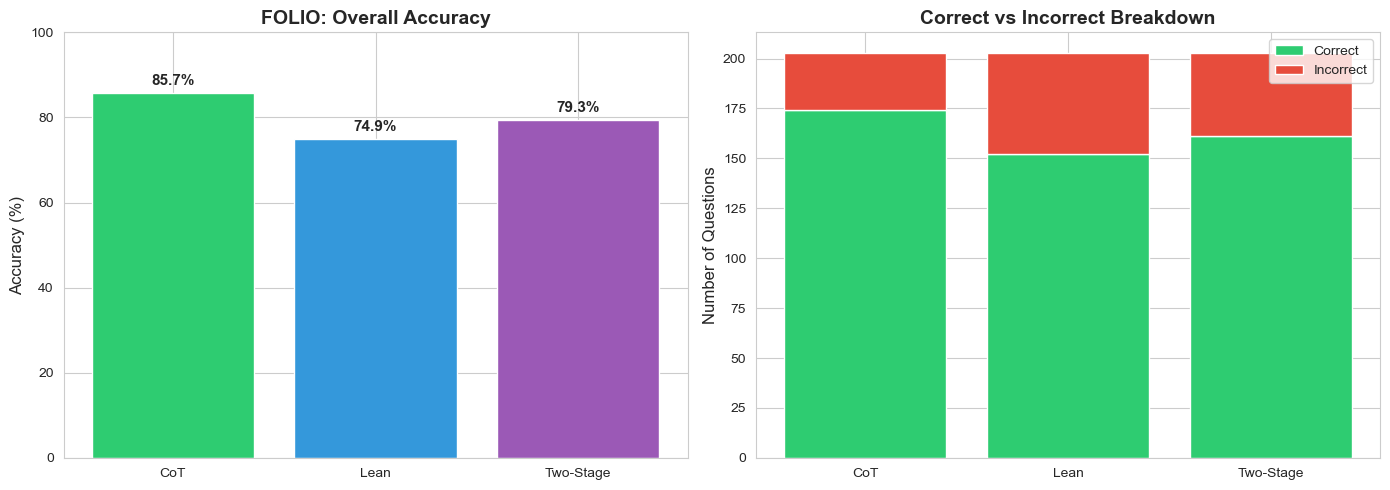

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
approaches = ['CoT', 'Lean', 'Two-Stage']
accuracies = [cot_acc, lean_acc, two_stage_acc]
colors = ['#2ecc71', '#3498db', '#9b59b6']

bars = ax1.bar(approaches, accuracies, color=colors)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('FOLIO: Overall Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Correct/Incorrect breakdown
correct_counts = [sum(1 for r in cot_sorted if r['correct']),
                  sum(1 for r in lean_sorted if r['correct']),
                  sum(1 for r in two_stage_sorted if r['correct'])]
incorrect_counts = [203 - c for c in correct_counts]

x = np.arange(3)
ax2.bar(x, correct_counts, label='Correct', color='#2ecc71')
ax2.bar(x, incorrect_counts, bottom=correct_counts, label='Incorrect', color='#e74c3c')
ax2.set_xticks(x)
ax2.set_xticklabels(approaches)
ax2.set_ylabel('Number of Questions', fontsize=12)
ax2.set_title('Correct vs Incorrect Breakdown', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Hypothesis Testing: Why Does Lean Fail?

### Hypothesis 1: Lean Verification Fails Frequently

In [78]:
# Check Lean verification success rates
lean_verified = sum(1 for r in lean_sorted if r.get('lean_verification', {}).get('success', False))
lean_failed = len(lean_sorted) - lean_verified

two_stage_verified = 0
two_stage_failed = 0
for r in two_stage_sorted:
    if 'all_cycles' in r and r['all_cycles']:
        final_cycle = r['all_cycles'][-1]
        if final_cycle.get('lean_success', False):
            two_stage_verified += 1
        else:
            two_stage_failed += 1

print("="*70)
print("HYPOTHESIS 1: Lean Verification Fails Frequently")
print("="*70)
print(f"\nLean:")
print(f"  Verified:  {lean_verified}/{len(lean_sorted)} ({lean_verified/len(lean_sorted)*100:.1f}%)")
print(f"  Failed:    {lean_failed}/{len(lean_sorted)} ({lean_failed/len(lean_sorted)*100:.1f}%)")

print(f"\nTwo-Stage:")
print(f"  Verified:  {two_stage_verified}/{len(two_stage_sorted)} ({two_stage_verified/len(two_stage_sorted)*100:.1f}%)")
print(f"  Failed:    {two_stage_failed}/{len(two_stage_sorted)} ({two_stage_failed/len(two_stage_sorted)*100:.1f}%)")

print(f"\nHYPOTHESIS REJECTED")
print(f"Verification success rate is very high (>96%)")
print(f"Models CAN write syntactically valid Lean code")
print("="*70)

HYPOTHESIS 1: Lean Verification Fails Frequently

Lean:
  Verified:  195/203 (96.1%)
  Failed:    8/203 (3.9%)

Two-Stage:
  Verified:  196/203 (96.6%)
  Failed:    7/203 (3.4%)

HYPOTHESIS REJECTED
Verification success rate is very high (>96%)
Models CAN write syntactically valid Lean code


### Hypothesis 2: Verified Lean Code Proves Wrong Answer

HYPOTHESIS 2: Verified Lean Code Proves Wrong Answer

Lean (among 195 verified):
  Correct answer:   146 (74.9%)
  Wrong answer:     49 (25.1%)

Two-Stage (among 196 verified):
  Correct answer:   155 (79.1%)
  Wrong answer:     41 (20.9%)

HYPOTHESIS CONFIRMED
49 Lean cases (25.1%) are verified but WRONG
41 Two-Stage cases (20.9%) are verified but WRONG
Lean verification does not guarantee logical correctness


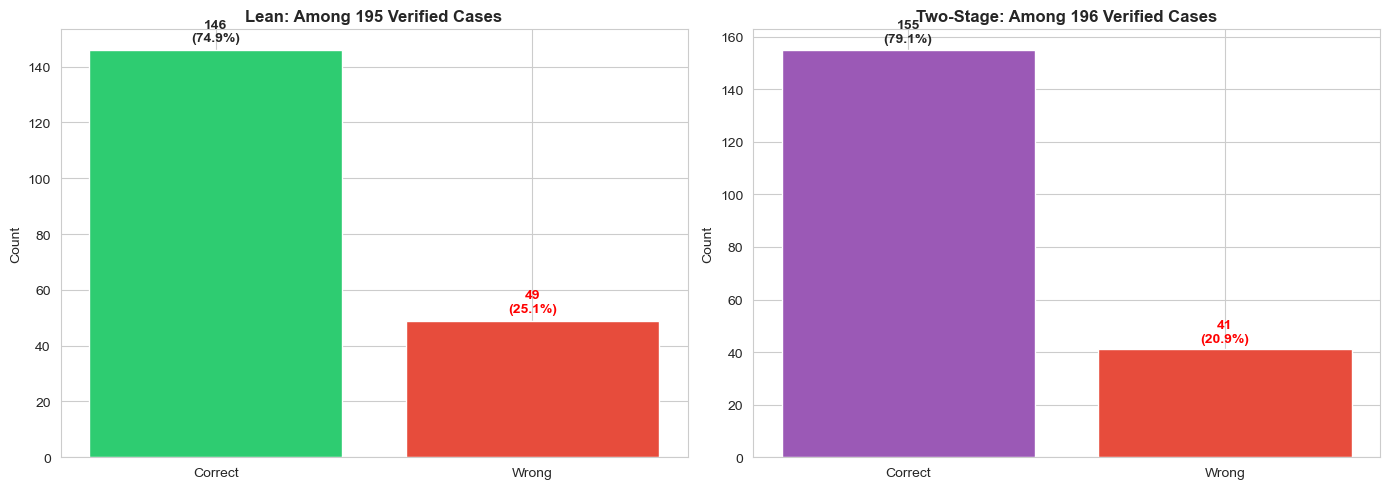

In [79]:
# Check: among verified Lean code, how many are correct vs wrong?
lean_verified_correct = sum(1 for r in lean_sorted 
                             if r.get('lean_verification', {}).get('success', False) and r['correct'])
lean_verified_wrong = sum(1 for r in lean_sorted 
                          if r.get('lean_verification', {}).get('success', False) and not r['correct'])

two_stage_verified_correct = 0
two_stage_verified_wrong = 0
for r in two_stage_sorted:
    if 'all_cycles' in r and r['all_cycles'] and r['all_cycles'][-1].get('lean_success', False):
        if r['correct']:
            two_stage_verified_correct += 1
        else:
            two_stage_verified_wrong += 1

print("="*70)
print("HYPOTHESIS 2: Verified Lean Code Proves Wrong Answer")
print("="*70)
print(f"\nLean (among {lean_verified} verified):")
print(f"  Correct answer:   {lean_verified_correct} ({lean_verified_correct/lean_verified*100:.1f}%)")
print(f"  Wrong answer:     {lean_verified_wrong} ({lean_verified_wrong/lean_verified*100:.1f}%)")

print(f"\nTwo-Stage (among {two_stage_verified} verified):")
print(f"  Correct answer:   {two_stage_verified_correct} ({two_stage_verified_correct/two_stage_verified*100:.1f}%)")
print(f"  Wrong answer:     {two_stage_verified_wrong} ({two_stage_verified_wrong/two_stage_verified*100:.1f}%)")

print(f"\nHYPOTHESIS CONFIRMED")
print(f"{lean_verified_wrong} Lean cases ({lean_verified_wrong/lean_verified*100:.1f}%) are verified but WRONG")
print(f"{two_stage_verified_wrong} Two-Stage cases ({two_stage_verified_wrong/two_stage_verified*100:.1f}%) are verified but WRONG")
print(f"Lean verification does not guarantee logical correctness")
print("="*70)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(['Correct', 'Wrong'], [lean_verified_correct, lean_verified_wrong], color=['#2ecc71', '#e74c3c'])
ax1.set_ylabel('Count')
ax1.set_title(f'Lean: Among {lean_verified} Verified Cases', fontweight='bold')
ax1.text(0, lean_verified_correct + 3, f'{lean_verified_correct}\n({lean_verified_correct/lean_verified*100:.1f}%)', 
         ha='center', fontweight='bold')
ax1.text(1, lean_verified_wrong + 3, f'{lean_verified_wrong}\n({lean_verified_wrong/lean_verified*100:.1f}%)', 
         ha='center', fontweight='bold', color='red')

ax2.bar(['Correct', 'Wrong'], [two_stage_verified_correct, two_stage_verified_wrong], color=['#9b59b6', '#e74c3c'])
ax2.set_ylabel('Count')
ax2.set_title(f'Two-Stage: Among {two_stage_verified} Verified Cases', fontweight='bold')
ax2.text(0, two_stage_verified_correct + 3, f'{two_stage_verified_correct}\n({two_stage_verified_correct/two_stage_verified*100:.1f}%)', 
         ha='center', fontweight='bold')
ax2.text(1, two_stage_verified_wrong + 3, f'{two_stage_verified_wrong}\n({two_stage_verified_wrong/two_stage_verified*100:.1f}%)', 
         ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## 4. Root Cause Analysis: The Axiomatization Problem

Let's examine a concrete example of where Lean goes wrong.

**The Axiomatization Problem:**

Line 28 uses: `axiom Joey_is_Wild : WildTurkey Joey`

This **axiomatizes the conclusion** instead of proving it from premises. The model assumes Joey is a wild turkey (the thing being questioned) rather than deriving it logically.

**Why Lean accepts it:**
- Code is syntactically valid (compiles successfully)
- But logically incorrect (assumes what should be proven)

**Key distinction:**
- `axiom Joey : Entity` - Correct (declaring an individual exists)
- `axiom Joey_is_Wild : WildTurkey Joey` - Wrong (axiomatizing a property to be proven)

In [80]:
# Find example where CoT correct but Lean verified but wrong
for cot, lean in zip(cot_sorted, lean_sorted):
    if (cot['correct'] and not lean['correct'] and 
        lean.get('lean_verification', {}).get('success', False) and
        cot['example_id'] == 2):
        
        print("="*70)
        print("Example ID:", cot['example_id'])
        print("Conclusion:", cot.get('conclusion', 'N/A'))
        print("Ground Truth:", cot['ground_truth'])
        print()
        print("CoT Prediction:", cot['prediction'], "(Correct)")
        print("Lean Prediction:", lean['prediction'], "(Wrong but verified)")
        
        print("\n" + "="*70)
        print("LEAN CODE EXCERPT:")
        print("="*70)
        lean_code = lean.get('lean_code', '')
        lines = lean_code.split('\n')
        for i, line in enumerate(lines[:35], 1):
            if 'axiom' in line.lower() and 'Joey' in line and ('Wild' in line or 'Turkey' in line):
                print(f"Line {i:2d}: {line}  <- PROBLEM: Axiomatizing conclusion")
            else:
                print(f"Line {i:2d}: {line}")
        break

Example ID: 2
Conclusion: Joey is a wild turkey.
Ground Truth: Unknown

CoT Prediction: Unknown (Correct)
Lean Prediction: True (Wrong but verified)

LEAN CODE EXCERPT:
Line  1: axiom Entity : Type
Line  2: 
Line  3: axiom Tom : Entity
Line  4: axiom Joey : Entity
Line  5: 
Line  6: axiom WildTurkey : Entity → Prop
Line  7: axiom Eastern : Entity → Prop
Line  8: axiom Osceola : Entity → Prop
Line  9: axiom Goulds : Entity → Prop
Line 10: axiom Merriams : Entity → Prop
Line 11: axiom RioGrande : Entity → Prop
Line 12: axiom Ocellated : Entity → Prop
Line 13: 
Line 14: -- Exhaustiveness of wild turkey types
Line 15: axiom wild_exhaustive :
Line 16:   ∀ x, WildTurkey x →
Line 17:     Eastern x ∨ Osceola x ∨ Goulds x ∨ Merriams x ∨ RioGrande x ∨ Ocellated x
Line 18: 
Line 19: -- Premises about Tom
Line 20: axiom Tom_not_Eastern : ¬ Eastern Tom
Line 21: axiom Tom_not_Osceola : ¬ Osceola Tom
Line 22: axiom Tom_not_Goulds : ¬ Goulds Tom
Line 23: axiom Tom_not_Merriams : ¬ Merriams Tom
Line 24

## 5. Prompt Analysis: Is the Prompt to Blame?

Let's examine the prompts to understand why this happens.

**Key Findings from Prompt Analysis:**

The Lean prompt has several critical deficiencies:

1. **No clear distinction** between premises (should axiomatize) vs conclusions (should prove)
   - Models axiomatize conclusions instead of proving them
   - Example: `axiom Joey_is_Wild : WildTurkey Joey` when Joey being wild is the question!

2. **Vague instructions**: "pay close attention to predicates and entities"
   - Doesn't specify WHAT to do with them
   - No concrete guidance on formalization strategy

3. **No guidance on "Unknown"**: 
   - Should mean: unprovable from given premises alone
   - Models instead: axiomatize missing facts!

4. **No warning against axiomatizing conclusions**
   - Models freely use `axiom` for anything, including the goal
   - This makes Lean accept the proof as syntactically valid

5. **No examples** showing correct vs incorrect axiomatization
   - No reference for proper formalization patterns

In contrast, the **CoT prompt is simple and effective**:
- Direct instruction to reason step-by-step
- No translation layer → no formalization errors
- Clear output format (True/False/Unknown)

In [81]:
# Load prompts from actual files
with open('../prompts/folio/cot_system.txt', 'r') as f:
    cot_prompt = f.read()

with open('../prompts/folio/lean_system.txt', 'r') as f:
    lean_prompt = f.read()

print("="*70)
print("CoT PROMPT")
print("="*70)
print(cot_prompt)

print("\n" + "="*70)
print("LEAN PROMPT")
print("="*70)
print(lean_prompt)

print("\n" + "="*70)
print("KEY DIFFERENCES")
print("="*70)
print("\n1. CoT: Simple, direct instruction")
print("   → 'analyze context and answer by reasoning step-by-step'")
print("\n2. Lean: Complex translation task")
print("   → 'translate natural language → Lean code → prove theorem'")
print("\n3. CoT: No formalization required")
print("   → Model reasons directly in natural language")
print("\n4. Lean: Translation introduces errors")
print("   → Model must correctly axiomatize premises vs prove conclusions")
print("="*70)

CoT PROMPT
You are a logical reasoning assistant. Your task is to carefully analyze the given context and answer questions by reasoning step-by-step.

For each question, think through the logic carefully before providing your answer. Each answer should be exactly one of: True, False, or Unknown.

IMPORTANT: After your reasoning for all questions, provide your final answers in exactly this format:

ANSWERS:
1: True/False/Unknown
2: True/False/Unknown
3: True/False/Unknown
(Use the exact number of questions provided: {num_questions})

LEAN PROMPT
You are a logician with a background in mathematics that translates natural language reasoning text to Lean code so that these natural language reasoning problems can be solved. During the translation, please pay close attention to the predicates and entities. There is an additional requirement: I also want you to try to prove the theorem you translated to Lean. If you can prove the theorem, give me True at the end of the answer. If you can prov

## 6. Two-Stage Analysis: Does Iteration Help?

TWO-STAGE vs LEAN COMPARISON

Two-Stage improves over Lean:  22 cases
Two-Stage regresses from Lean: 13 cases
Both same (correct or wrong):  168 cases

Net improvement: 9 cases
Net accuracy gain: 4.43%

Two-stage DOES help (+9 cases, +4.4%)
But doesn't fully fix the axiomatization problem


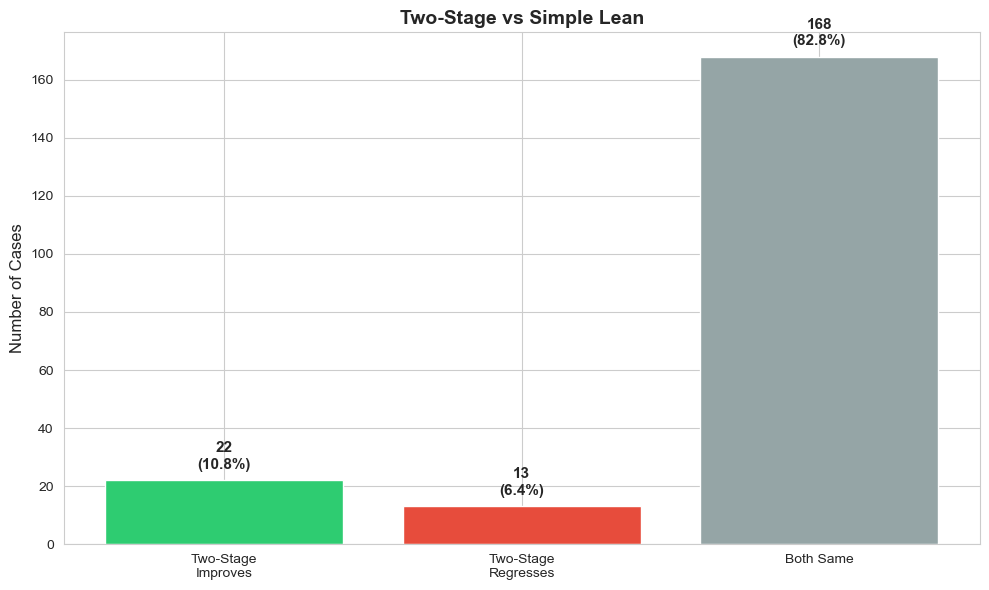

In [82]:
# Compare Lean vs Two-Stage
two_stage_improves = 0
two_stage_regresses = 0
both_same = 0

for lean, ts in zip(lean_sorted, two_stage_sorted):
    if not lean['correct'] and ts['correct']:
        two_stage_improves += 1
    elif lean['correct'] and not ts['correct']:
        two_stage_regresses += 1
    elif lean['correct'] == ts['correct']:
        both_same += 1

print("="*70)
print("TWO-STAGE vs LEAN COMPARISON")
print("="*70)
print(f"\nTwo-Stage improves over Lean:  {two_stage_improves} cases")
print(f"Two-Stage regresses from Lean: {two_stage_regresses} cases")
print(f"Both same (correct or wrong):  {both_same} cases")
print(f"\nNet improvement: {two_stage_improves - two_stage_regresses} cases")
print(f"Net accuracy gain: {(two_stage_improves - two_stage_regresses)/203*100:.2f}%")

print(f"\nTwo-stage DOES help (+{two_stage_improves - two_stage_regresses} cases, +4.4%)")
print(f"But doesn't fully fix the axiomatization problem")
print("="*70)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Two-Stage\nImproves', 'Two-Stage\nRegresses', 'Both Same']
counts = [two_stage_improves, two_stage_regresses, both_same]
colors_list = ['#2ecc71', '#e74c3c', '#95a5a6']

bars = ax.bar(categories, counts, color=colors_list)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Two-Stage vs Simple Lean', fontsize=14, fontweight='bold')

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3,
            f'{count}\n({count/203*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [83]:
# Calculate summary statistics
cot_correct = sum(1 for r in cot_sorted if r['correct'])
lean_correct = sum(1 for r in lean_sorted if r['correct'])
two_stage_correct = sum(1 for r in two_stage_sorted if r['correct'])
total_questions = len(cot_sorted)

# Calculate iterations correctly
# Lean: use 'num_iterations' field (Lean refinement iterations)
lean_avg_iterations = sum(r.get('num_iterations', 1) for r in lean_sorted) / len(lean_sorted)

# Two-Stage: sum all stage2_iterations across all cycles
total_lean_iterations_list = []
for r in two_stage_sorted:
    total_iters = 0
    if 'all_cycles' in r and r['all_cycles']:
        for cycle in r['all_cycles']:
            stage2_iters = cycle.get('stage2_iterations', [])
            if isinstance(stage2_iters, list):
                total_iters += len(stage2_iters)
            else:
                total_iters += 1
    total_lean_iterations_list.append(total_iters)
two_stage_avg_lean_iter = sum(total_lean_iterations_list) / len(total_lean_iterations_list)

# Create summary table
summary_data = {
    'Metric': [
        'Accuracy',
        'Correct Answers',
        'Verification Success',
        'Verified but Wrong',
        'Avg Lean Iterations'
    ],
    'CoT': [
        f'{cot_acc:.2f}%',
        f'{cot_correct}/{total_questions}',
        'N/A',
        'N/A',
        'N/A'
    ],
    'Lean': [
        f'{lean_acc:.2f}%',
        f'{lean_correct}/{total_questions}',
        f'{lean_verified}/{total_questions} ({lean_verified/total_questions*100:.1f}%)',
        f'{lean_verified_wrong} ({lean_verified_wrong/lean_verified*100:.1f}%)',
        f'{lean_avg_iterations:.2f}'
    ],
    'Two-Stage': [
        f'{two_stage_acc:.2f}%',
        f'{two_stage_correct}/{total_questions}',
        f'{two_stage_verified}/{total_questions} ({two_stage_verified/total_questions*100:.1f}%)',
        f'{two_stage_verified_wrong} ({two_stage_verified_wrong/two_stage_verified*100:.1f}%)',
        f'{two_stage_avg_lean_iter:.2f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)
print(f"\nWinner: CoT ({cot_acc:.2f}%)")
print(f"Lean verification hurts by: {cot_acc - lean_acc:.2f}%")
print(f"Two-stage improves Lean by: {two_stage_acc - lean_acc:.2f}%")
print("Root cause: Axiomatization of conclusions")
print("="*70)


FINAL PERFORMANCE SUMMARY
              Metric     CoT            Lean       Two-Stage
            Accuracy  85.71%          74.88%          79.31%
     Correct Answers 174/203         152/203         161/203
Verification Success     N/A 195/203 (96.1%) 196/203 (96.6%)
  Verified but Wrong     N/A      49 (25.1%)      41 (20.9%)
 Avg Lean Iterations     N/A            1.22            1.79

Winner: CoT (85.71%)
Lean verification hurts by: 10.84%
Two-stage improves Lean by: 4.43%
Root cause: Axiomatization of conclusions
